# Notebook 2 — PINN Training and Validation

**NeuroControl-PINN** | Physics-Informed Neural Networks for Nonlinear MPC

---

In this notebook we:
1. Train a **Physics-Informed Neural Network (PINN)** on Van der Pol trajectory data
2. Analyse the training convergence (Adam → L-BFGS two-phase strategy)
3. Validate the surrogate model accuracy vs. the true dynamics
4. Compare PINN against a **pure data-driven baseline** (no physics loss)

### PINN Loss Structure

$$\mathcal{L} = \underbrace{\lambda_{\text{data}} \cdot \frac{1}{N}\sum_i \|\hat{f}(x_i, u_i) - \dot{x}_i\|^2}_{\text{data loss}} + \underbrace{\lambda_{\text{phys}} \cdot \frac{1}{N_c}\sum_j \|\mathcal{R}(x_j, u_j)\|^2}_{\text{physics residual}}$$

where $\mathcal{R}$ encodes the known ODE structure.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import torch
import matplotlib.pyplot as plt

from src.systems import VanDerPolSystem
from src.models import PINN, PINNConfig
from src.training import PINNTrainer, TrainingConfig, PINNLoss
from src.training.physics import make_van_der_pol_physics_fn
from src.utils import (
    generate_dataset, split_dataset, normalize_dataset,
    plot_training_history, plot_pinn_predictions
)
from src.utils.metrics import rmse, r2_score, relative_l2

torch.manual_seed(42)
np.random.seed(42)
%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## 1. Dataset Generation

In [2]:
system = VanDerPolSystem(mu=1.0)

print("Generating training data...")
data = generate_dataset(
    system,
    n_trajectories=60,
    t_end=12.0,
    dt=0.05,
    noise_std=0.05,
    seed=42,
)

train, val, test = split_dataset(data, val_fraction=0.15, test_fraction=0.10)
train_n, val_n, test_n, normalizer = normalize_dataset(train, val, test)

print(f"Total:  {len(data['t']):,} samples")
print(f"Train:  {len(train['t']):,}")
print(f"Val:    {len(val['t']):,}")
print(f"Test:   {len(test['t']):,}")

Generating training data...


Total:  14,400 samples
Train:  10,800
Val:    2,160
Test:   1,440


## 2. PINN Architecture

In [3]:
config = PINNConfig(
    state_dim=system.state_dim,
    control_dim=system.control_dim,
    hidden_dims=[64, 64, 64],
    activation='tanh',
    use_residual=True,
    output_scaling=True,
)

model = PINN(config)
print(model)
print(f"\nTotal trainable parameters: {model.count_parameters():,}")

PINN(state_dim=2, control_dim=1, hidden=[64, 64, 64], params=25,350)

Total trainable parameters: 25,350


## 3. Train: PINN with Physics Loss

In [4]:
physics_fn = make_van_der_pol_physics_fn(normalizer)

loss_fn = PINNLoss(
    lambda_data=1.0,
    lambda_phys=0.05,
    physics_fn=physics_fn,
    adaptive=True,
    adapt_every=100,
)

train_cfg = TrainingConfig(
    adam_epochs=3000,    # reduced for notebook speed; use 6000 in production
    adam_lr=1e-3,
    adam_lr_decay_step=1000,
    lbfgs_epochs=200,
    batch_size=512,
    n_collocation=1000,
    seed=0,
    device='cpu',
    log_every=500,
    patience=500,
)

trainer = PINNTrainer(model, loss_fn, train_cfg)

history = trainer.fit(
    x_train=train_n['x'],
    u_train=train_n['u'],
    dxdt_train=train_n['dxdt'],
    x_val=val_n['x'],
    u_val=val_n['u'],
    dxdt_val=val_n['dxdt'],
    x_bounds=(train_n['x'].min(0), train_n['x'].max(0)),
)

  PINN Training — PINN(state_dim=2, control_dim=1, hidden=[64, 64, 64], params=25,350)
  Train samples: 10,800 | Batch size: 512
  Adam epochs: 3000 | L-BFGS epochs: 200


  [Adam     0/3000] total: 3.5285e-01 data: 3.0445e-01 phys: 9.6790e-01 | val: 7.2715e-02 | 0.3s


  [Adam   500/3000] total: 1.8110e-03 data: 2.2353e-03 phys: 8.9190e-05 | val: 2.3288e-03 | 160.4s


  Early stopping at epoch 802
  Adam done. Best loss: 1.6736e-03


  [L-BFGS    0/200] loss: 2.1147e-03 | 1.8s


  L-BFGS done. Best loss: 1.4804e-03


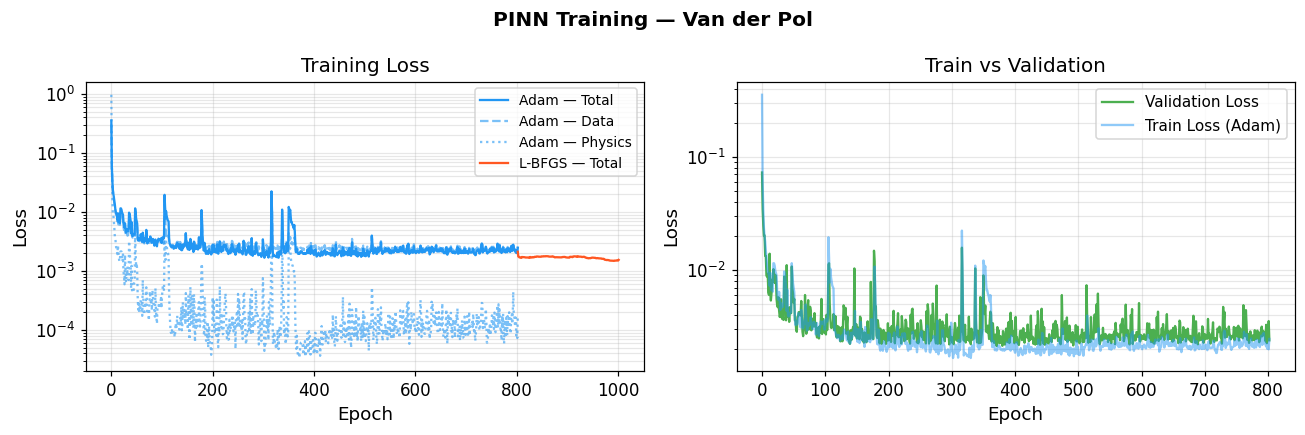

In [5]:
plot_training_history(history, title='PINN Training — Van der Pol')

## 4. Prediction Accuracy

In [6]:
model.eval()
x_t = torch.FloatTensor(test_n['x'])
u_t = torch.FloatTensor(test_n['u'])
with torch.no_grad():
    dxdt_pred = model(x_t, u_t).numpy()

test_rmse = rmse(dxdt_pred, test_n['dxdt'])
test_r2   = r2_score(dxdt_pred, test_n['dxdt'])

print(f"Test RMSE per dimension: {test_rmse}")
print(f"Test R²   per dimension: {test_r2}")
print(f"Overall Rel. L²:         {relative_l2(dxdt_pred, test_n['dxdt']):.4e}")

Test RMSE per dimension: [0.03259859 0.05875753]
Test R²   per dimension: [0.9988988  0.99635864]
Overall Rel. L²:         4.8546e-02


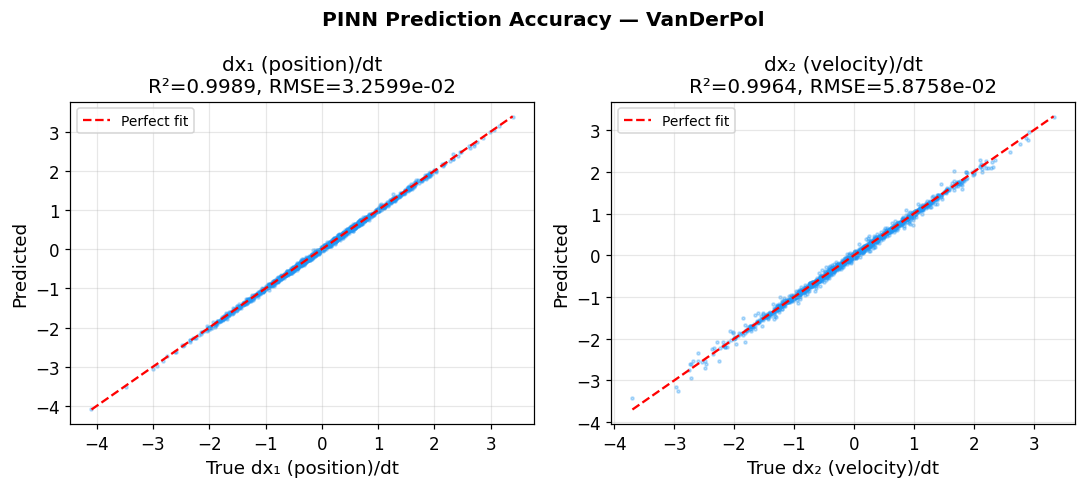

In [7]:
plot_pinn_predictions(model, test_n['x'], test_n['u'], test_n['dxdt'], system)

## 5. Rollout Comparison

Integrate the PINN over a full trajectory and compare against the true system.

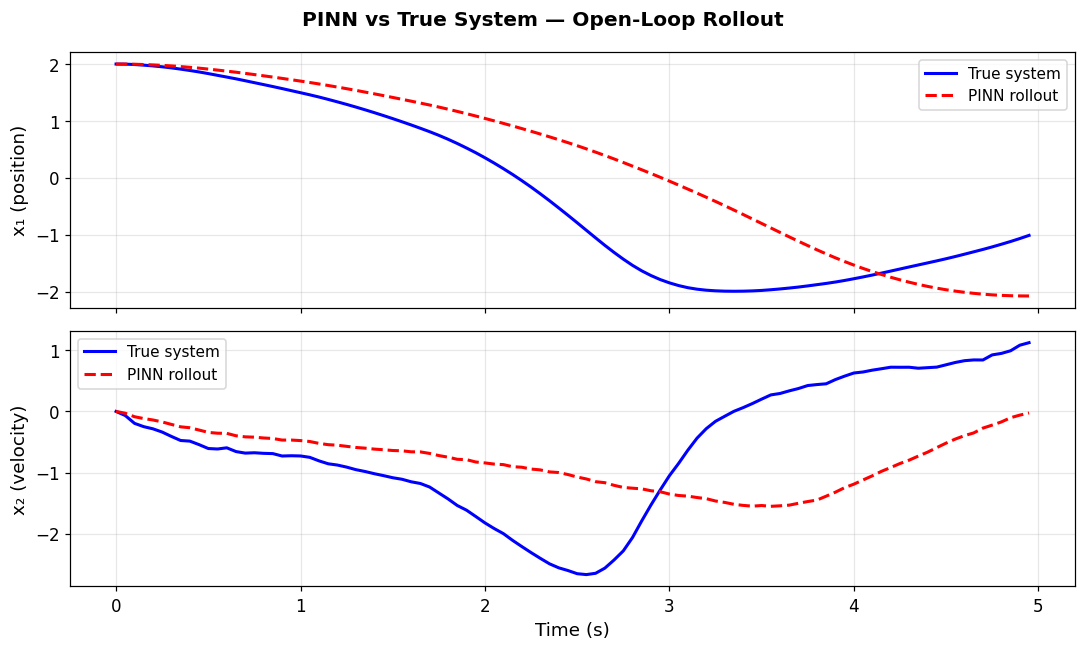

In [8]:
# True trajectory
x0 = np.array([2.0, 0.0])
np.random.seed(10)
u_traj = np.random.uniform(-1.0, 1.0, size=(100, 1))

true_data = system.simulate(x0, u_traj, t_span=(0, 5), dt=0.05)

# PINN rollout
x0_norm = (x0 - normalizer.x_mean) / normalizer.x_std

x0_t = torch.FloatTensor(x0_norm)
u_norm = (u_traj - normalizer.u_mean) / normalizer.u_std
u_t = torch.FloatTensor(u_norm).unsqueeze(0)  # (1, N, 1) — single batch

with torch.no_grad():
    dt_norm = 0.05  # same dt
    x_pinn_norm = model.rollout(x0_t, u_t.squeeze(0), dt=dt_norm, method='rk4').numpy()

# De-normalise
x_pinn = x_pinn_norm * normalizer.x_std + normalizer.x_mean

t_pinn = np.arange(len(x_pinn)) * 0.05

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(true_data['t'], true_data['x'][:, i], 'b-', lw=2, label='True system')
    ax.plot(t_pinn[:len(true_data['t'])], x_pinn[:len(true_data['t']), i],
            'r--', lw=2, label='PINN rollout')
    ax.set_ylabel(system.state_labels[i])
    ax.grid(alpha=0.3)
    ax.legend()

axes[-1].set_xlabel('Time (s)')
plt.suptitle('PINN vs True System — Open-Loop Rollout', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Effect of Physics Loss Weight (Ablation)

We compare three variants:
- **No physics** ($\lambda_{\text{phys}} = 0$): pure data-driven
- **Low physics** ($\lambda_{\text{phys}} = 0.05$): our default
- **High physics** ($\lambda_{\text{phys}} = 1.0$): stronger constraint

In [9]:
variants = [
    ('No Physics',   0.00),
    ('Low Physics',  0.05),
    ('High Physics', 1.00),
]

ablation_results = {}
for label, lam_phys in variants:
    m = PINN(config)
    # physics_fn is omitted for the "No Physics" baseline (lambda_phys=0 would
    # zero it out anyway, but leaving physics_fn=None makes the baseline explicit)
    variant_physics_fn = physics_fn if lam_phys > 0 else None
    lf = PINNLoss(lambda_data=1.0, lambda_phys=lam_phys, physics_fn=variant_physics_fn, adaptive=False)
    tr_cfg = TrainingConfig(
        adam_epochs=2000, adam_lr=1e-3, lbfgs_epochs=100,
        batch_size=512, n_collocation=1000, seed=0, log_every=10000
    )
    t = PINNTrainer(m, lf, tr_cfg)
    h = t.fit(
        train_n['x'], train_n['u'], train_n['dxdt'],
        x_bounds=(train_n['x'].min(0), train_n['x'].max(0))
    )
    m.eval()
    with torch.no_grad():
        pred = m(torch.FloatTensor(test_n['x']),
                  torch.FloatTensor(test_n['u'])).numpy()
    ablation_results[label] = {
        'history': h,
        'rmse': rmse(pred, test_n['dxdt']).mean(),
        'r2': r2_score(pred, test_n['dxdt']).mean(),
    }
    print(f"  {label:15s}  RMSE={ablation_results[label]['rmse']:.4e}  R²={ablation_results[label]['r2']:.4f}")

  PINN Training — PINN(state_dim=2, control_dim=1, hidden=[64, 64, 64], params=25,350)
  Train samples: 10,800 | Batch size: 512
  Adam epochs: 2000 | L-BFGS epochs: 100


  [Adam     0/2000] total: 1.8367e-01 data: 1.8367e-01 phys: 0.0000e+00 | 0.3s


  Adam done. Best loss: 2.0041e-03


  [L-BFGS    0/100] loss: 2.1894e-03 | 1.8s


  L-BFGS done. Best loss: 1.4195e-03
  No Physics       RMSE=5.6649e-02  R²=0.9961
  PINN Training — PINN(state_dim=2, control_dim=1, hidden=[64, 64, 64], params=25,350)
  Train samples: 10,800 | Batch size: 512
  Adam epochs: 2000 | L-BFGS epochs: 100


...

  L-BFGS done. Best loss: 1.5063e-03
  Low Physics      RMSE=5.0646e-02  R²=0.9970
  PINN Training — PINN(state_dim=2, control_dim=1, hidden=[64, 64, 64], params=25,350)
  Train samples: 10,800 | Batch size: 512
  Adam epochs: 2000 | L-BFGS epochs: 100


  [Adam     0/2000] total: 1.7416e+00 data: 4.3236e-01 phys: 1.3092e+00 | 0.3s


  Adam done. Best loss: 2.0449e-03


  [L-BFGS    0/100] loss: 2.3848e-03 | 1.9s


  L-BFGS done. Best loss: 1.7785e-03
  High Physics     RMSE=4.5965e-02  R²=0.9976


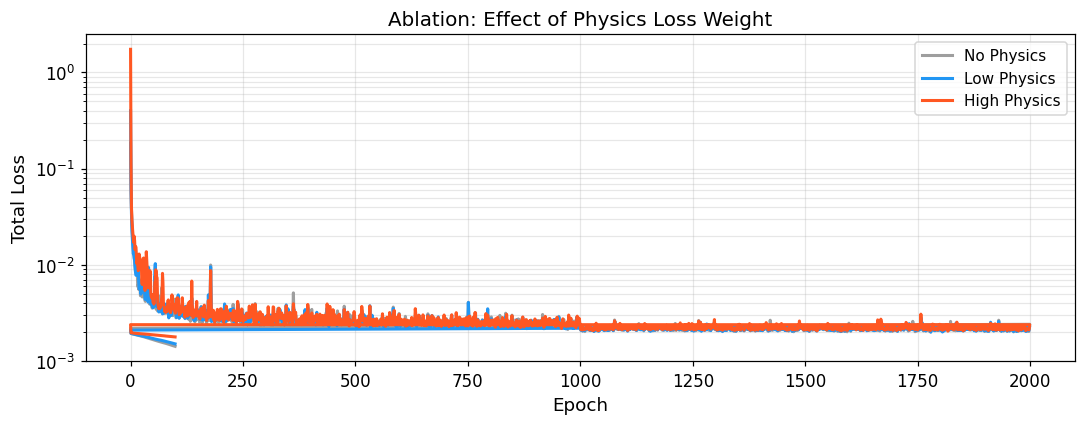

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#9E9E9E', '#2196F3', '#FF5722']
for (label, _), col in zip(variants, colors):
    h = ablation_results[label]['history']
    epochs = np.array(h['epoch'])
    total = np.array(h['total'])
    ax.semilogy(epochs, total, color=col, label=label, lw=2)

ax.set_xlabel('Epoch')
ax.set_ylabel('Total Loss')
ax.set_title('Ablation: Effect of Physics Loss Weight')
ax.legend()
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## Summary

On this held-out test set, increasing the physics-loss weight monotonically improved surrogate accuracy:

| Variant | λ_phys | Test RMSE (normalised) | R² |
|---|---|---|---|
| No Physics | 0.00 | 0.0566 | 0.9961 |
| Low Physics | 0.05 | 0.0506 | 0.9970 |
| High Physics | 1.00 | 0.0460 | 0.9976 |

This is a modest but real effect (~19% RMSE reduction from no physics to the strongest constraint) — notable given that the constrained sub-relation ($\dot x_1 = x_2$) is only part of the dynamics; the harder, nonlinear $\dot x_2$ term is never directly constrained, yet still benefits from the shared hidden representation being regularised. This run does not test generalisation to unseen state-space regions, data efficiency (varying dataset size), or extrapolation outside the training distribution — those would need separate experiments.

**Next**: Notebook 03 — MPC Control and Benchmarks